<a href="https://colab.research.google.com/github/Adi212004/Customer-Segmentation-using-ML/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

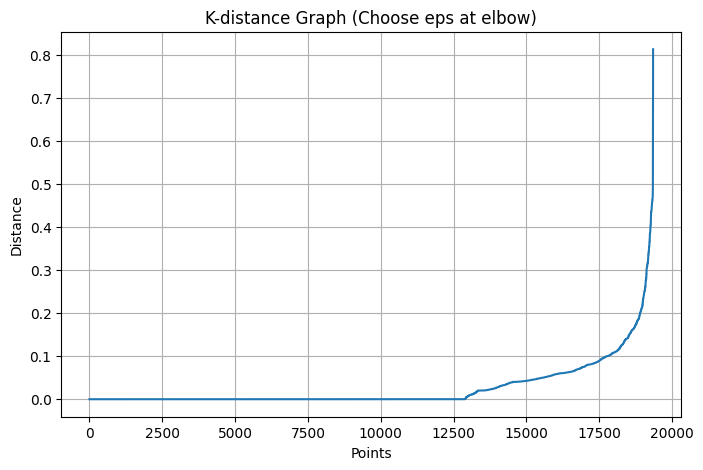


Cluster Counts:
Cluster
2      3000
1      2667
8      2575
16     1688
19     1536
       ... 
251       6
287       6
288       6
290       6
291       6
Name: count, Length: 293, dtype: int64

Cluster Means (RFM):
            recency  frequency     monetary
Cluster                                    
-1       163.828571   3.371429  2118.457690
 0        53.459559   3.000000  1635.458493
 1        34.564304   7.000000  3806.044068
 2        42.120000   6.000000  3221.781740
 3       119.250000   7.000000  4107.362500
...             ...        ...          ...
 287     231.500000   3.000000   421.175000
 288     218.000000   6.000000  5880.330000
 289       0.000000   7.000000  9633.410000
 290     174.500000   3.000000  3363.630000
 291      30.000000   6.000000  7109.400000

[293 rows x 3 columns]


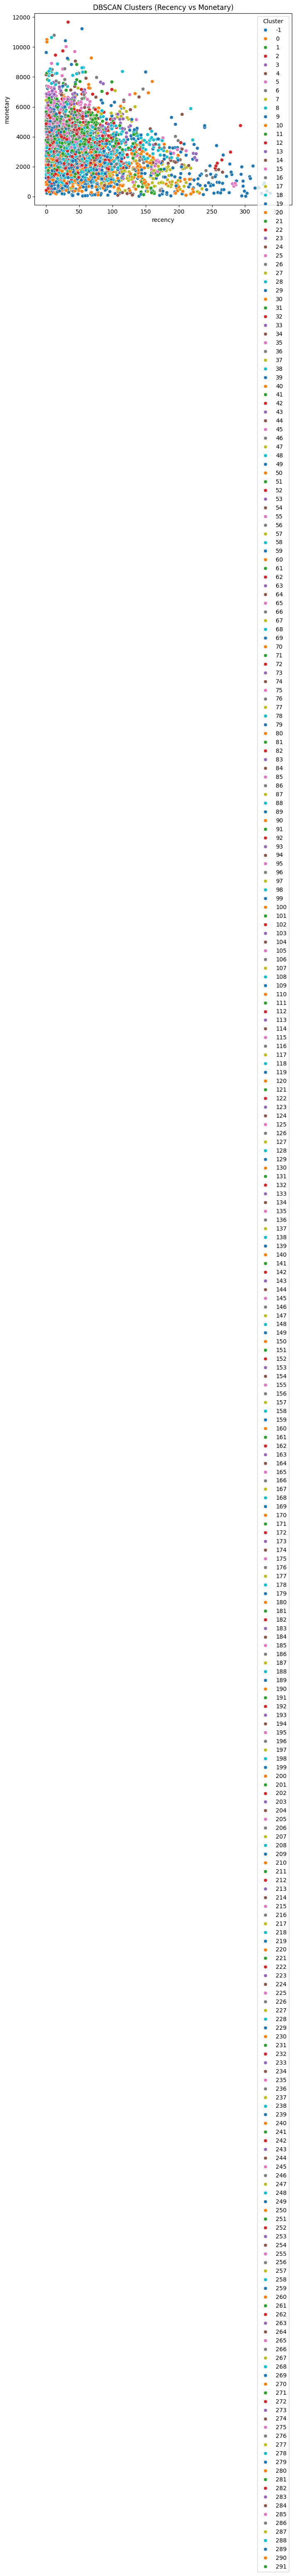


File saved as 'dbscan_segmented_customers.csv'


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN


df = pd.read_csv("Customer_Trans_RFM_Analysis.csv")

# -------------------------------
# 2. Select RFM Features
# -------------------------------
X = df[['recency', 'frequency', 'monetary']]

# -------------------------------
# 3. Scale the Data
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. K-Distance Graph (for eps)
# -------------------------------
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 5])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("Distance")
plt.title("K-distance Graph (Choose eps at elbow)")
plt.grid()
plt.show()

# -------------------------------
# 5. Apply DBSCAN
# -------------------------------
# 👉 Change eps after observing graph
dbscan = DBSCAN(eps=0.2, min_samples=6)

clusters = dbscan.fit_predict(X_scaled)
df['Cluster'] = clusters

# -------------------------------
# 6. Cluster Summary
# -------------------------------
print("\nCluster Counts:")
print(df['Cluster'].value_counts())

print("\nCluster Means (RFM):")
print(df.groupby('Cluster')[['recency','frequency','monetary']].mean())

# -------------------------------
# 7. Visualization
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['recency'],
    y=df['monetary'],
    hue=df['Cluster'],
    palette='tab10'
)
plt.title("DBSCAN Clusters (Recency vs Monetary)")
plt.show()

# -------------------------------
# 8. Save Output
# -------------------------------
df.to_csv("dbscan_segmented_customers.csv", index=False)

print("\nFile saved as 'dbscan_segmented_customers.csv'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
